# Modul 14 — Computer Vision Dasar (OpenCV)
## Convergeni Data Consulting (CDC) — Klien: PT Komponen Jaya

Notebook ini menjalankan seluruh pipeline computer vision Modul 14: gambar
komponen sintetis, grayscale, konvolusi Sobel, deteksi tepi Canny, dan sistem
QC berbasis ambang batas jumlah piksel tepi.

## Membuat Gambar Komponen Sintetis

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def buat_komponen(dengan_cacat, seed):
    rng = np.random.RandomState(seed)
    img = np.ones((300, 300, 3), dtype=np.uint8) * 220
    cv2.circle(img, (150, 150), 100, (160, 160, 160), -1)
    cv2.circle(img, (150, 150), 100, (100, 100, 100), 3)
    cv2.circle(img, (150, 150), 35, (220, 220, 220), -1)
    cv2.circle(img, (150, 150), 35, (100, 100, 100), 2)
    noise = rng.normal(0, 4, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    if dengan_cacat:
        x1, y1 = rng.randint(70, 130), rng.randint(70, 200)
        x2, y2 = x1 + rng.randint(60, 120), y1 + rng.randint(-40, 80)
        cv2.line(img, (x1, y1), (x2, y2), (60, 60, 60), 2)
    return img

img_normal = buat_komponen(dengan_cacat=False, seed=42)
img_cacat = buat_komponen(dengan_cacat=True, seed=43)
print("Shape:", img_normal.shape)
print("Piksel tengah (BGR):", img_normal[150, 150])

Shape: (300, 300, 3)
Piksel tengah (BGR): [222 214 222]


## Visualisasi 1: Anatomi Gambar, dari Warna ke Grayscale ke Tepi (Asset Baru, mengganti M14-01)

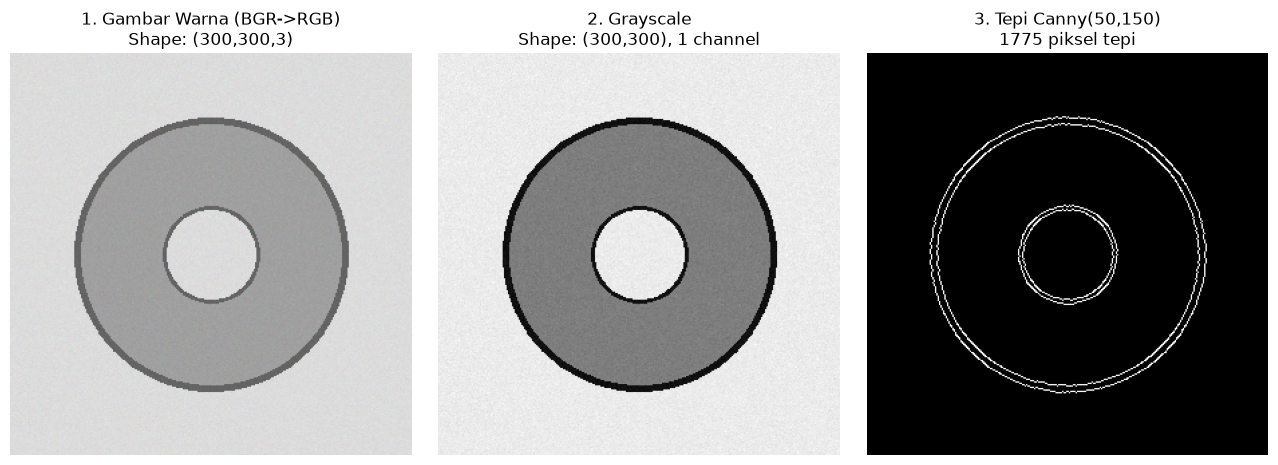

In [2]:
gray_normal = cv2.cvtColor(img_normal, cv2.COLOR_BGR2GRAY)
edges_normal = cv2.Canny(gray_normal, 50, 150)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(cv2.cvtColor(img_normal, cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Gambar Warna (BGR->RGB)\nShape: (300,300,3)")
axes[1].imshow(gray_normal, cmap="gray")
axes[1].set_title("2. Grayscale\nShape: (300,300), 1 channel")
axes[2].imshow(edges_normal, cmap="gray")
axes[2].set_title(f"3. Tepi Canny(50,150)\n{int(np.sum(edges_normal>0))} piksel tepi")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("modul14_anatomi_gambar.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisasi 2: Normal vs Cacat, Gambar dan Peta Tepi Berdampingan (Asset Baru, mengganti M14-02)

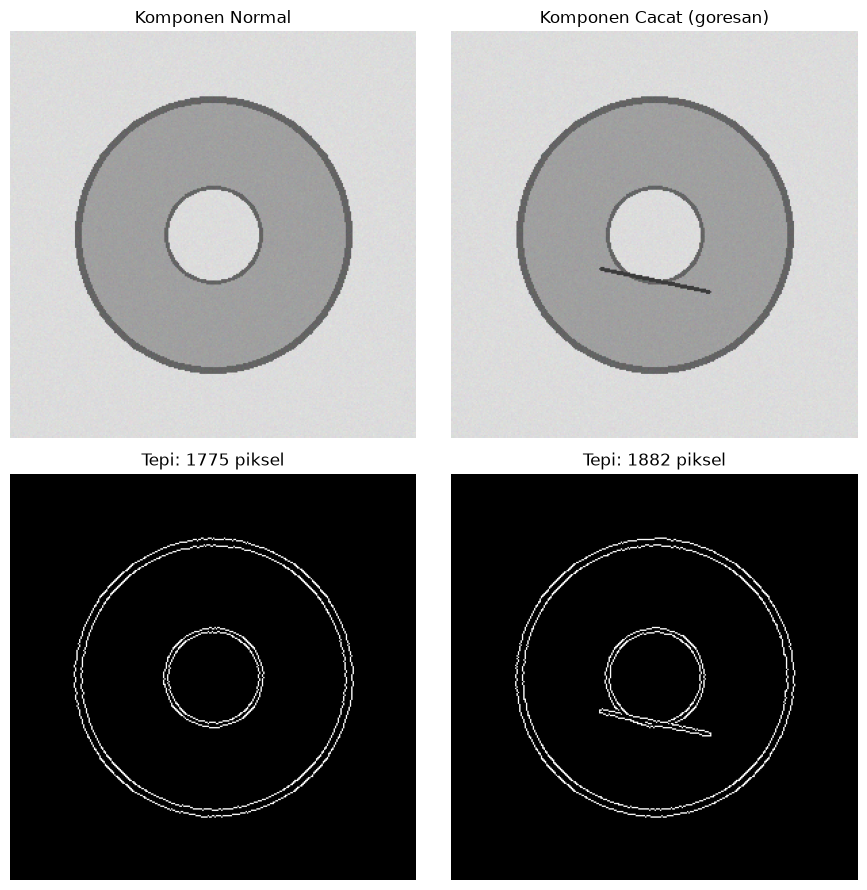

Normal: 1775 piksel tepi, Cacat: 1882 piksel tepi


In [3]:
gray_cacat = cv2.cvtColor(img_cacat, cv2.COLOR_BGR2GRAY)
edges_cacat = cv2.Canny(gray_cacat, 50, 150)
n_edge_normal = int(np.sum(edges_normal > 0))
n_edge_cacat = int(np.sum(edges_cacat > 0))

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
axes[0,0].imshow(cv2.cvtColor(img_normal, cv2.COLOR_BGR2RGB)); axes[0,0].set_title("Komponen Normal")
axes[0,1].imshow(cv2.cvtColor(img_cacat, cv2.COLOR_BGR2RGB)); axes[0,1].set_title("Komponen Cacat (goresan)")
axes[1,0].imshow(edges_normal, cmap="gray"); axes[1,0].set_title(f"Tepi: {n_edge_normal} piksel")
axes[1,1].imshow(edges_cacat, cmap="gray"); axes[1,1].set_title(f"Tepi: {n_edge_cacat} piksel")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.savefig("modul14_normal_vs_cacat.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Normal: {n_edge_normal} piksel tepi, Cacat: {n_edge_cacat} piksel tepi")

## Sistem QC: 30 Normal vs 30 Cacat

In [4]:
import pandas as pd

def hitung_edge(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    return int(np.sum(edges > 0))

hasil = []
for i in range(30):
    img_n = buat_komponen(dengan_cacat=False, seed=1000 + i)
    img_c = buat_komponen(dengan_cacat=True, seed=2000 + i)
    hasil.append({"cacat_asli": 0, "jumlah_edge": hitung_edge(img_n)})
    hasil.append({"cacat_asli": 1, "jumlah_edge": hitung_edge(img_c)})

df = pd.DataFrame(hasil)
print(df.groupby("cacat_asli")["jumlah_edge"].describe().round(2))

ambang_batas = (df[df.cacat_asli == 0]["jumlah_edge"].max() + df[df.cacat_asli == 1]["jumlah_edge"].min()) / 2
df["prediksi_cacat"] = (df["jumlah_edge"] > ambang_batas).astype(int)
akurasi = (df["prediksi_cacat"] == df["cacat_asli"]).mean()
print(f"Ambang batas: {ambang_batas}, Akurasi: {akurasi:.4f}")

            count     mean    std     min      25%     50%      75%     max
cacat_asli                                                                 
0            30.0  1782.40   4.15  1775.0  1779.00  1782.0  1785.75  1792.0
1            30.0  1970.97  49.65  1874.0  1939.25  1957.0  2005.25  2071.0
Ambang batas: 1833.0, Akurasi: 1.0000


## Visualisasi 3: Distribusi Jumlah Piksel Tepi, Normal vs Cacat (Asset Baru)

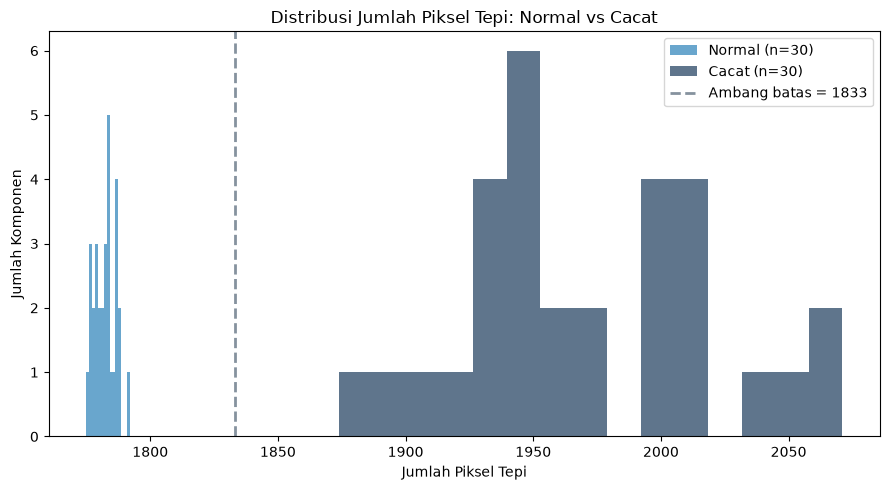

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df[df.cacat_asli==0]["jumlah_edge"], bins=15, alpha=0.7, color="#2980B9", label="Normal (n=30)")
ax.hist(df[df.cacat_asli==1]["jumlah_edge"], bins=15, alpha=0.7, color="#1B3A5C", label="Cacat (n=30)")
ax.axvline(ambang_batas, color="#85929E", linestyle="--", linewidth=2, label=f"Ambang batas = {ambang_batas:.0f}")
ax.set_xlabel("Jumlah Piksel Tepi")
ax.set_ylabel("Jumlah Komponen")
ax.set_title("Distribusi Jumlah Piksel Tepi: Normal vs Cacat")
ax.legend()
plt.tight_layout()
plt.savefig("modul14_distribusi_edge.png", dpi=150, bbox_inches="tight")
plt.show()